yolo标注的格式比较简洁，大概就是

```
3 0.560071 0.087838 0.30742 0.141892
2 0.475265 0.836993 0.328622 0.089527
0 0.517668 0.717061 0.85159 0.501689
```

第一个是class id，不用过多解释；

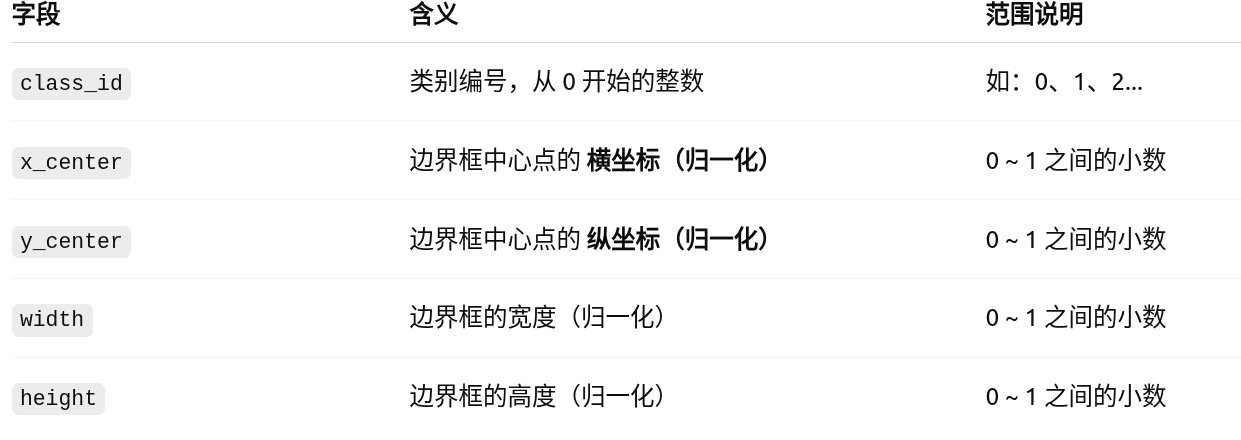

In [28]:
import os
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms

class YoloDataset(Dataset):
    def __init__(self, image_folder, label_folder, transform=None):
        self.image_folder = image_folder
        self.label_folder = label_folder
        self.image_names = os.listdir(self.image_folder)
        self.transform = transform

    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, index):
        image_name = self.image_names[index]
        image_path = os.path.join(self.image_folder, image_name)
        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label_name = image_name.split('.')[0] + '.txt'
        label_path = os.path.join(self.label_folder, label_name)
        with open(label_path) as f:
            label_centnet = f.read()
        objects = label_centnet.strip().split('\n')
        target = []
        for object in objects:
            info_list = object.split(' ')
            class_id = float(info_list[0])
            center_x=float(info_list[1])
            center_y=float(info_list[2])
            width=float(info_list[3])
            height=float(info_list[4])
            target.append([class_id,center_x,center_y,width,height])
        return image,target
    



In [29]:
image_folder='400_data/Dataset_Motor/images'
label_folder='400_data/Dataset_Motor/labels'
transform_ops = transforms.ToTensor() 
train_data=YoloDataset(image_folder,label_folder,transform_ops)
print(train_data[0])

(tensor([[[0.8588, 0.8667, 0.8667,  ..., 0.8784, 0.8784, 0.8784],
         [0.8627, 0.8667, 0.8667,  ..., 0.8784, 0.8784, 0.8784],
         [0.8627, 0.8667, 0.8667,  ..., 0.8824, 0.8824, 0.8824],
         ...,
         [0.6314, 0.6314, 0.6314,  ..., 0.5294, 0.5294, 0.5294],
         [0.6314, 0.6314, 0.6314,  ..., 0.5294, 0.5294, 0.5294],
         [0.6314, 0.6314, 0.6314,  ..., 0.5294, 0.5294, 0.5294]],

        [[0.8745, 0.8706, 0.8706,  ..., 0.8549, 0.8549, 0.8549],
         [0.8745, 0.8745, 0.8745,  ..., 0.8549, 0.8549, 0.8549],
         [0.8745, 0.8745, 0.8745,  ..., 0.8588, 0.8588, 0.8588],
         ...,
         [0.6118, 0.6118, 0.6118,  ..., 0.5216, 0.5216, 0.5216],
         [0.6118, 0.6118, 0.6118,  ..., 0.5216, 0.5216, 0.5216],
         [0.6118, 0.6118, 0.6118,  ..., 0.5216, 0.5216, 0.5216]],

        [[0.8980, 0.8980, 0.8980,  ..., 0.8314, 0.8314, 0.8314],
         [0.8980, 0.8980, 0.8980,  ..., 0.8353, 0.8353, 0.8353],
         [0.8980, 0.9020, 0.9020,  ..., 0.8353, 0.8353, 0